# 01 - Analisis Exploratorio de Datos (EDA)

Objetivo: explorar `ANALYTICS.OBT_TRIPS_MODEL` sin descargar los 844M de filas a memoria local. El notebook usa consultas agregadas en Snowflake y baja solo una muestra pequena para graficos y correlaciones.

Reglas de trabajo:
- No usar `train_test_split` local.
- No cargar la tabla completa en pandas.
- Validar cobertura temporal y ausencia de leakage antes de analizar modelos.
- Usar el `TEST_SET` solo para medicion final, no para tomar decisiones de limpieza/modelado.


## 1) Setup y conexion


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snowflake.connector

# Buscar la raiz del proyecto desde notebooks/ o desde la raiz.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import get_project_config

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

cfg = get_project_config(required=True)
model_table = cfg.fq_table(cfg.obt_model_table)
train_table = cfg.fq_table(cfg.train_table)
val_table = cfg.fq_table(cfg.val_table)
test_table = cfg.fq_table(cfg.test_table)
target = cfg.target_column

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Database:", cfg.snowflake.database)
print("Analytics schema:", cfg.analytics_schema)
print("Model table:", model_table)
print("Target:", target)


PROJECT_ROOT: F:\Data mining\Proyecto Final
Database: DATA_MINING_DB
Analytics schema: ANALYTICS
Model table: ANALYTICS.OBT_TRIPS_MODEL
Target: TOTAL_AMOUNT


In [2]:
def get_connection():
    return snowflake.connector.connect(**cfg.snowflake.connector_kwargs)


def query_df(sql: str) -> pd.DataFrame:
    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute(sql)
            return cur.fetch_pandas_all()


context_df = query_df("""
SELECT CURRENT_DATABASE() AS database_name,
       CURRENT_SCHEMA() AS schema_name,
       CURRENT_ROLE() AS role_name,
       CURRENT_WAREHOUSE() AS warehouse_name
""")
context_df


,DATABASE_NAME,SCHEMA_NAME,ROLE_NAME,WAREHOUSE_NAME
0,DATA_MINING_DB,ANALYTICS,DATA_MINING_ROLE,COMPUTE_WH


## 2) Validacion de tablas, splits y leakage


In [3]:
summary_df = query_df(f"""
SELECT 'OBT_TRIPS_MODEL' AS object_name,
       COUNT(*) AS rows_total,
       MIN(YEAR) AS min_year,
       MAX(YEAR) AS max_year,
       ROUND(AVG({target}), 2) AS avg_target
FROM {model_table}
UNION ALL
SELECT 'TRAIN_SET' AS object_name,
       COUNT(*) AS rows_total,
       MIN(YEAR) AS min_year,
       MAX(YEAR) AS max_year,
       ROUND(AVG({target}), 2) AS avg_target
FROM {train_table}
UNION ALL
SELECT 'VAL_SET' AS object_name,
       COUNT(*) AS rows_total,
       MIN(YEAR) AS min_year,
       MAX(YEAR) AS max_year,
       ROUND(AVG({target}), 2) AS avg_target
FROM {val_table}
UNION ALL
SELECT 'TEST_SET' AS object_name,
       COUNT(*) AS rows_total,
       MIN(YEAR) AS min_year,
       MAX(YEAR) AS max_year,
       ROUND(AVG({target}), 2) AS avg_target
FROM {test_table}
ORDER BY object_name
""")
summary_df


,OBJECT_NAME,ROWS_TOTAL,MIN_YEAR,MAX_YEAR,AVG_TARGET
0,OBT_TRIPS_MODEL,844000986,2015,2025,18.6300
1,TEST_SET,44109224,2025,2025,28.7600
2,TRAIN_SET,760168027,2015,2023,17.5200
3,VAL_SET,39723735,2024,2024,28.5500


In [4]:
coverage_df = query_df(f"""
SELECT SERVICE_TYPE,
       YEAR,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_total_amount,
       ROUND(AVG(TRIP_DISTANCE), 2) AS avg_trip_distance
FROM {model_table}
GROUP BY 1, 2
ORDER BY 1, 2
""")
coverage_df


,SERVICE_TYPE,YEAR,ROWS_TOTAL,AVG_TOTAL_AMOUNT,AVG_TRIP_DISTANCE
0,green,2015,18677121,14.7800,2.9400
1,green,2016,15852655,14.6700,2.8500
2,green,2017,11396364,14.3000,2.7300
3,green,2018,8640576,16.2300,3.3100
4,green,2019,6029300,18.3800,3.6700
5,green,2020,1638399,20.3200,4.1400
6,green,2021,1008763,24.1300,4.8000
7,green,2022,771364,18.8900,3.3100
8,green,2023,728065,23.6300,3.1000
9,green,2024,606984,24.0900,2.9700


In [5]:
forbidden_columns = [
    'DROPOFF_DATETIME', 'DROPOFF_DATE', 'DROPOFF_HOUR',
    'FARE_AMOUNT', 'EXTRA', 'MTA_TAX', 'TIP_AMOUNT', 'TOLLS_AMOUNT',
    'IMPROVEMENT_SURCHARGE', 'CONGESTION_SURCHARGE', 'AIRPORT_FEE',
    'TRIP_DURATION_MIN', 'AVG_SPEED_MPH', 'TIP_PCT',
    'PAYMENT_TYPE', 'PAYMENT_TYPE_DESC', 'RUN_ID', 'INGESTED_AT_UTC',
    'SOURCE_SERVICE', 'SOURCE_YEAR', 'SOURCE_MONTH'
]
forbidden_sql = ", ".join(f"'{col}'" for col in forbidden_columns)

leakage_df = query_df(f"""
SELECT COLUMN_NAME
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_SCHEMA = '{cfg.analytics_schema.upper()}'
  AND TABLE_NAME = '{cfg.obt_model_table.upper()}'
  AND COLUMN_NAME IN ({forbidden_sql})
ORDER BY COLUMN_NAME
""")

if leakage_df.empty:
    print("OK: no hay columnas de leakage en OBT_TRIPS_MODEL.")
else:
    display(leakage_df)
    raise ValueError("Hay columnas de leakage en la tabla de modelado.")


OK: no hay columnas de leakage en OBT_TRIPS_MODEL.


## 3) Analisis univariado del target

Se calculan percentiles en Snowflake. Esto permite entender la distribucion sin mover cientos de millones de filas a pandas.


In [6]:
target_stats_df = query_df(f"""
SELECT COUNT(*) AS rows_total,
       MIN({target}) AS min_target,
       APPROX_PERCENTILE({target}, 0.01) AS p01,
       APPROX_PERCENTILE({target}, 0.05) AS p05,
       APPROX_PERCENTILE({target}, 0.25) AS p25,
       APPROX_PERCENTILE({target}, 0.50) AS p50,
       APPROX_PERCENTILE({target}, 0.75) AS p75,
       APPROX_PERCENTILE({target}, 0.90) AS p90,
       APPROX_PERCENTILE({target}, 0.95) AS p95,
       APPROX_PERCENTILE({target}, 0.99) AS p99,
       MAX({target}) AS max_target,
       AVG({target}) AS avg_target,
       STDDEV({target}) AS std_target
FROM {model_table}
""")
target_stats_df


,ROWS_TOTAL,MIN_TARGET,P01,P05,P25,P50,P75,P90,P95,P99,MAX_TARGET,AVG_TARGET,STD_TARGET
0,844000986,0.0100,4.8000,6.3000,9.8000,13.8000,20.8352,34.8848,51.2438,81.4949,500.0000,18.6289,15.7141


In [7]:
target_by_service_df = query_df(f"""
SELECT SERVICE_TYPE,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_target,
       APPROX_PERCENTILE({target}, 0.50) AS p50,
       APPROX_PERCENTILE({target}, 0.90) AS p90,
       APPROX_PERCENTILE({target}, 0.99) AS p99
FROM {model_table}
GROUP BY 1
ORDER BY 1
""")
target_by_service_df


,SERVICE_TYPE,ROWS_TOTAL,AVG_TARGET,P50,P90,P99
0,green,65894448,15.7900,11.8001,29.7403,62.0881
1,yellow,778106538,18.8700,14.0525,35.5271,82.6620


## 4) Muestra para graficos locales

La muestra se obtiene con `SAMPLE BERNOULLI`, limitada a un tamano manejable. No representa un split de entrenamiento; solo sirve para EDA visual.


In [8]:
SAMPLE_PCT = 0.01
SAMPLE_LIMIT = 100_000

sample_df = query_df(f"""
SELECT {target},
       SERVICE_TYPE,
       VENDOR_ID,
       RATE_CODE_ID,
       TRIP_TYPE,
       PASSENGER_COUNT,
       TRIP_DISTANCE,
       PICKUP_HOUR,
       DAY_OF_WEEK,
       MONTH,
       YEAR,
       IS_WEEKEND,
       SAME_BOROUGH_FLAG,
       AIRPORT_TRIP_FLAG,
       PU_BOROUGH,
       DO_BOROUGH,
       PU_LOCATION_ID,
       DO_LOCATION_ID
FROM {model_table} SAMPLE BERNOULLI ({SAMPLE_PCT})
LIMIT {SAMPLE_LIMIT}
""")

print(sample_df.shape)
sample_df.head()


(84318, 18)


,TOTAL_AMOUNT,SERVICE_TYPE,VENDOR_ID,RATE_CODE_ID,TRIP_TYPE,PASSENGER_COUNT,TRIP_DISTANCE,PICKUP_HOUR,DAY_OF_WEEK,MONTH,YEAR,IS_WEEKEND,SAME_BOROUGH_FLAG,AIRPORT_TRIP_FLAG,PU_BOROUGH,DO_BOROUGH,PU_LOCATION_ID,DO_LOCATION_ID
0,14.3000,yellow,2,1.0000,NaN,1.0000,1.2800,22,3,5,2023,0,1,0,Manhattan,Manhattan,229,262
1,16.1000,yellow,2,1.0000,NaN,3.0000,1.6800,14,1,5,2023,1,1,0,Manhattan,Manhattan,74,236
2,21.0000,yellow,1,1.0000,NaN,1.0000,2.2000,11,1,5,2023,1,1,0,Manhattan,Manhattan,234,163
3,27.2400,yellow,2,1.0000,NaN,2.0000,2.8900,1,7,5,2023,1,1,0,Manhattan,Manhattan,161,125
4,15.1200,yellow,2,1.0000,NaN,3.0000,1.2800,9,6,5,2023,0,1,0,Manhattan,Manhattan,234,161


In [9]:
sample_df.dtypes


TOTAL_AMOUNT         float64
SERVICE_TYPE          object
VENDOR_ID               int8
RATE_CODE_ID         float64
TRIP_TYPE            float64
PASSENGER_COUNT      float64
TRIP_DISTANCE        float64
PICKUP_HOUR             int8
DAY_OF_WEEK             int8
MONTH                   int8
YEAR                   int16
IS_WEEKEND              int8
SAME_BOROUGH_FLAG       int8
AIRPORT_TRIP_FLAG       int8
PU_BOROUGH            object
DO_BOROUGH            object
PU_LOCATION_ID         int16
DO_LOCATION_ID         int16
dtype: object

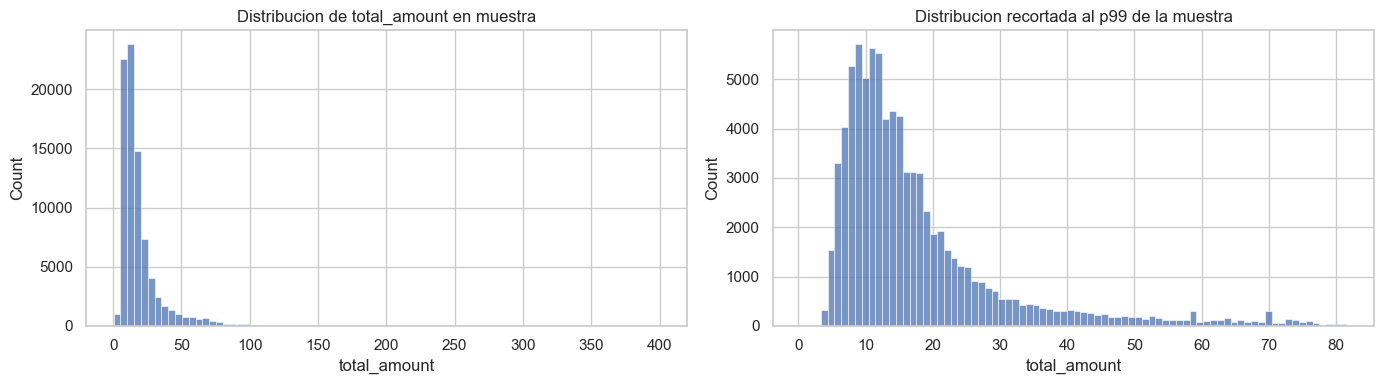

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(sample_df[target], bins=80, ax=axes[0])
axes[0].set_title("Distribucion de total_amount en muestra")
axes[0].set_xlabel("total_amount")

p99_sample = sample_df[target].quantile(0.99)
sns.histplot(sample_df.loc[sample_df[target] <= p99_sample, target], bins=80, ax=axes[1])
axes[1].set_title("Distribucion recortada al p99 de la muestra")
axes[1].set_xlabel("total_amount")

plt.tight_layout()


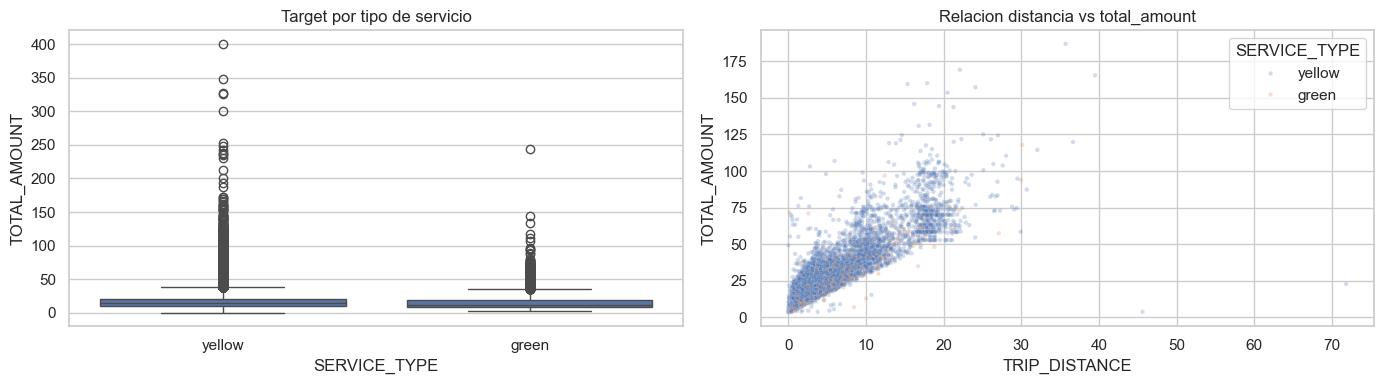

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=sample_df, x="SERVICE_TYPE", y=target, ax=axes[0])
axes[0].set_title("Target por tipo de servicio")

plot_df = sample_df.sample(min(len(sample_df), 20_000), random_state=cfg.random_state)
sns.scatterplot(data=plot_df, x="TRIP_DISTANCE", y=target, hue="SERVICE_TYPE", alpha=0.25, s=10, ax=axes[1])
axes[1].set_title("Relacion distancia vs total_amount")

plt.tight_layout()


## 5) Analisis bivariado con agregaciones SQL


,PICKUP_HOUR,ROWS_TOTAL,AVG_TOTAL_AMOUNT,P50_TOTAL_AMOUNT,P90_TOTAL_AMOUNT
0,0,27790382,18.7100,14.2931,34.5146
1,1,19768589,17.6100,13.8006,31.2780
2,2,14074219,16.9800,13.7298,29.8054
3,3,10095425,17.5300,13.8000,31.4820
4,4,7748926,20.3500,14.7636,40.5218


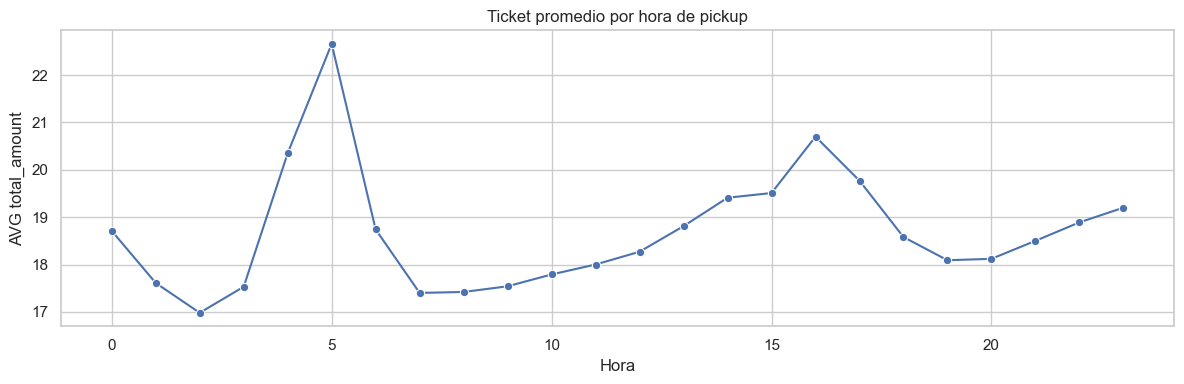

In [12]:
hour_df = query_df(f"""
SELECT PICKUP_HOUR,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_total_amount,
       APPROX_PERCENTILE({target}, 0.50) AS p50_total_amount,
       APPROX_PERCENTILE({target}, 0.90) AS p90_total_amount
FROM {model_table}
GROUP BY 1
ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=hour_df, x="PICKUP_HOUR", y="AVG_TOTAL_AMOUNT", marker="o", ax=ax)
ax.set_title("Ticket promedio por hora de pickup")
ax.set_xlabel("Hora")
ax.set_ylabel("AVG total_amount")
plt.tight_layout()
hour_df.head()


,YEAR,MONTH,SERVICE_TYPE,ROWS_TOTAL,AVG_TOTAL_AMOUNT
0,2015,1,green,1465848,14.1200
1,2015,1,yellow,12604463,14.7600
2,2015,2,green,1532155,14.4400
3,2015,2,yellow,12308075,15.3200
4,2015,3,green,1673990,14.5200


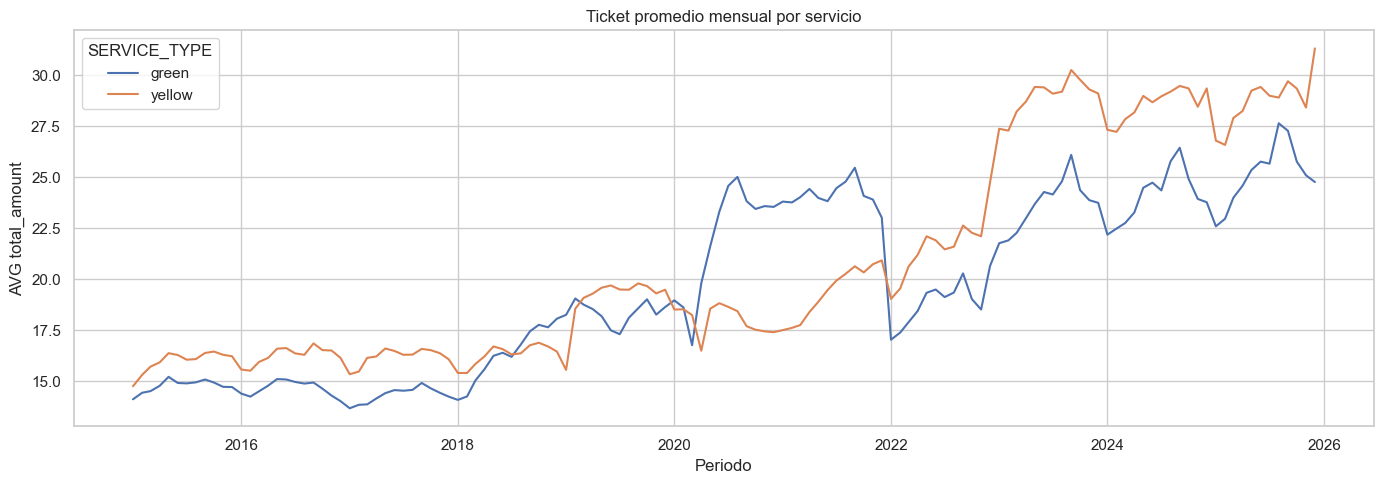

In [13]:
month_df = query_df(f"""
SELECT YEAR,
       MONTH,
       SERVICE_TYPE,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_total_amount
FROM {model_table}
GROUP BY 1, 2, 3
ORDER BY 1, 2, 3
""")

fig, ax = plt.subplots(figsize=(14, 5))
plot_month_df = month_df.copy()
plot_month_df["PERIOD"] = pd.to_datetime(plot_month_df["YEAR"].astype(str) + "-" + plot_month_df["MONTH"].astype(str).str.zfill(2) + "-01")
sns.lineplot(data=plot_month_df, x="PERIOD", y="AVG_TOTAL_AMOUNT", hue="SERVICE_TYPE", ax=ax)
ax.set_title("Ticket promedio mensual por servicio")
ax.set_xlabel("Periodo")
ax.set_ylabel("AVG total_amount")
plt.tight_layout()
month_df.head()


In [14]:
borough_df = query_df(f"""
SELECT PU_BOROUGH,
       DO_BOROUGH,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_total_amount,
       ROUND(AVG(TRIP_DISTANCE), 2) AS avg_trip_distance
FROM {model_table}
GROUP BY 1, 2
ORDER BY rows_total DESC
LIMIT 30
""")
borough_df


,PU_BOROUGH,DO_BOROUGH,ROWS_TOTAL,AVG_TOTAL_AMOUNT,AVG_TRIP_DISTANCE
0,Manhattan,Manhattan,669899247,14.4300,1.9300
1,Queens,Manhattan,30890386,58.0500,13.0600
2,Queens,Queens,28629656,18.5000,3.9500
3,Manhattan,Queens,25661572,45.8400,10.4600
4,Brooklyn,Brooklyn,24894247,13.9900,2.4200
5,Manhattan,Brooklyn,21638037,30.3900,6.3300
6,Queens,Brooklyn,8274768,49.1700,12.5800
7,Brooklyn,Manhattan,7123921,27.5600,5.8200
8,Unknown,Unknown,7078037,16.4500,2.8800
9,Manhattan,Bronx,5324682,28.6200,7.2200


In [15]:
top_pairs_df = query_df(f"""
SELECT PU_LOCATION_ID,
       DO_LOCATION_ID,
       COUNT(*) AS rows_total,
       ROUND(AVG({target}), 2) AS avg_total_amount,
       ROUND(AVG(TRIP_DISTANCE), 2) AS avg_trip_distance
FROM {model_table}
GROUP BY 1, 2
ORDER BY rows_total DESC
LIMIT 25
""")
top_pairs_df


,PU_LOCATION_ID,DO_LOCATION_ID,ROWS_TOTAL,AVG_TOTAL_AMOUNT,AVG_TRIP_DISTANCE
0,264,264,7078037,16.4500,2.8800
1,237,236,4516945,10.4800,1.0600
2,236,237,3860230,11.2800,1.0500
3,236,236,3435024,8.5200,0.6400
4,237,237,3298468,9.0800,0.6700
5,239,238,2001589,9.0000,0.8400
6,239,142,1987852,9.5500,0.8800
7,237,161,1935818,12.3100,1.0900
8,237,162,1922740,10.8700,0.9800
9,142,239,1903086,10.0100,0.9800


## 6) Correlaciones en muestra

Las correlaciones solo se calculan sobre variables numericas seguras y sobre la muestra. No se usan columnas de cierre del viaje.


TOTAL_AMOUNT         1.0000
TRIP_DISTANCE        0.8940
AIRPORT_TRIP_FLAG    0.6758
YEAR                 0.2611
MONTH                0.0377
PICKUP_HOUR          0.0154
PASSENGER_COUNT     -0.0042
DAY_OF_WEEK         -0.0166
IS_WEEKEND          -0.0287
DO_LOCATION_ID      -0.0568
PU_LOCATION_ID      -0.0593
SAME_BOROUGH_FLAG   -0.6649
Name: TOTAL_AMOUNT, dtype: float64

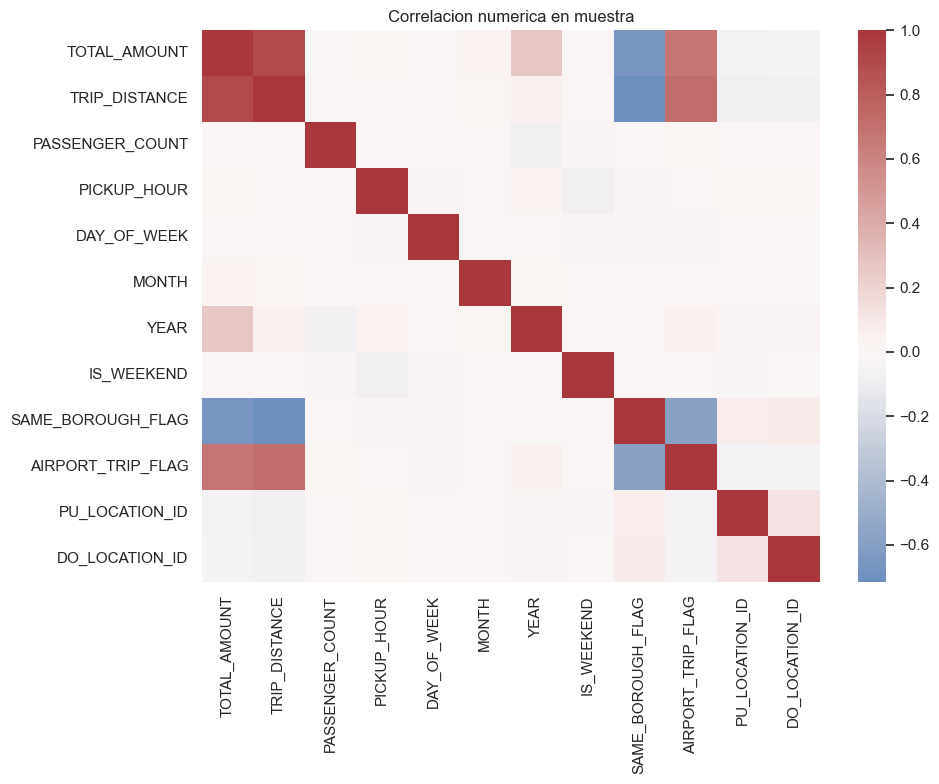

In [16]:
numeric_cols = [
    target,
    "TRIP_DISTANCE",
    "PASSENGER_COUNT",
    "PICKUP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "YEAR",
    "IS_WEEKEND",
    "SAME_BOROUGH_FLAG",
    "AIRPORT_TRIP_FLAG",
    "PU_LOCATION_ID",
    "DO_LOCATION_ID",
]

corr_df = sample_df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, cmap="vlag", center=0, annot=False, ax=ax)
ax.set_title("Correlacion numerica en muestra")
plt.tight_layout()

corr_df[target].sort_values(ascending=False)


## 7) Hallazgos para limpieza y feature engineering

Checklist para el notebook 02:
- La tabla de modelado esta completa: 2015-2025, 264 lotes.
- El split temporal ya esta creado en Snowflake: train 2015-2023, validacion 2024, test 2025.
- No hay columnas de leakage en `OBT_TRIPS_MODEL`.
- El target esta filtrado a valores positivos y plausibles.
- `TRIP_DISTANCE`, zonas, hora, dia, mes, servicio, rate code y flags de ruta son variables candidatas fuertes.
- `TRIP_NK`, `PICKUP_DATETIME` y `PICKUP_DATE` son utiles para trazabilidad/EDA, pero no deberian entrar directamente al modelo final.
- El `TEST_SET` queda reservado exclusivamente para la evaluacion final.
